# Notebook 03 — Predictive Modeling

## Project Context

The exploratory analysis demonstrated that the procurement dataset is complete, consistent and contains meaningful operational indicators describing supplier performance.

Building upon these findings, this notebook focuses on developing a machine learning model capable of predicting supplier compliance using historical procurement data.

The objective is not only to build an accurate predictive model, but also to understand the operational drivers influencing supplier performance and provide business recommendations based on the model's predictions.

## Notebook Objectives

## Notebook Objectives

The objectives of this notebook are to:

- load the processed procurement dataset;
- engineer predictive features from procurement data;
- prepare the dataset for machine learning;
- train and evaluate multiple classification models;
- compare model performance using complementary evaluation metrics;
- select the best-performing model based on the evaluation results;
- export the selected machine learning pipeline for deployment.

In [34]:
from pathlib import Path

import warnings

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    cross_val_score,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)


In [35]:
warnings.filterwarnings("ignore")

## Load the Processed Dataset

The processed procurement dataset generated during the exploratory analysis is loaded from the project's `data/processed` directory.

Using the processed dataset ensures that all subsequent analyses are based on consistent and validated procurement information before feature engineering and model development.

In [36]:

PROCESSED_DATA_DIR = Path("../data/processed").resolve()

csv_file = next(PROCESSED_DATA_DIR.glob("*.csv"))

procurement_df = pd.read_csv(csv_file)

In [37]:
print(f"Dataset shape: {procurement_df.shape}")

procurement_df.head()

Dataset shape: (10000, 12)


,PO_ID,Supplier,Item_Category,Order_Status,Order_Date,Delivery_Date,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Estimated_Spend
0,1,RailEngine,Body Structures,Delivered,2023-01-20,2023-03-21,141,7.62,5.11,6,1,720.51
1,2,MechaPrime,Bogies & Wheelsets,Delivered,2023-04-28,2023-07-10,418,123.54,87.66,76,1,36641.88
2,3,RailCom,HVAC Systems,Delivered,2023-12-29,2024-04-24,328,260.42,177.91,8,1,58354.48
3,4,RailMotion,Doors & Access Systems,Delivered,2023-05-08,2023-08-31,281,358.23,337.02,42,1,94702.62
4,5,ElectroParts,Brake Systems,Delivered,2023-10-05,2024-01-05,91,397.81,318.06,15,1,28943.46


## Data Preparation

The processed procurement dataset is now prepared for the machine learning phase.

Unlike the exploratory analysis, this notebook focuses on transforming the cleaned dataset into a format suitable for predictive modeling. The objective is to prepare features that can be used effectively by classification algorithms while preserving the business information identified during the exploratory phase.

The following steps include validating variable formats, preparing date and categorical features, defining the prediction target, and constructing the final modeling dataset.

## Assess Data Types

Before applying feature engineering, the data types of each variable are reviewed to ensure they are compatible with machine learning preprocessing techniques.

Particular attention is given to date variables, which require conversion to datetime format, and categorical variables, which will later be encoded into numerical representations suitable for predictive models.

In [38]:
data_types = (
    procurement_df
    .dtypes
    .rename("Data Type")
    .to_frame()
)

data_types

,Data Type
PO_ID,int64
Supplier,object
Item_Category,object
Order_Status,object
Order_Date,object
Delivery_Date,object
Quantity,int64
Unit_Price,float64
Negotiated_Price,float64
Defective_Units,int64


### Interpretation

The dataset contains a combination of numerical, categorical and date-related variables, providing the information required for predictive modeling.

Most numerical variables are already stored using appropriate numeric data types (`int64` and `float64`) and can be used directly for model training.

However, the `Order_Date` and `Delivery_Date` variables are currently stored as text (`object`). These variables must be converted to datetime format before extracting time-based features such as order month, delivery lead time or seasonal patterns.

The remaining categorical variables (`Supplier`, `Item_Category` and `Order_Status`) will require appropriate encoding during the preprocessing stage before they can be used by machine learning algorithms.

## Convert Date Variables

Date variables are essential for feature engineering because they capture the timing of procurement activities.

Before extracting time-based information, the `Order_Date` and `Delivery_Date` variables must be converted from text (`object`) to the `datetime` data type. This conversion enables the creation of meaningful features such as delivery lead time, order month, order quarter and other temporal patterns that may improve predictive model performance.

In [39]:
procurement_df["Order_Date"] = pd.to_datetime(procurement_df["Order_Date"])
procurement_df["Delivery_Date"] = pd.to_datetime(procurement_df["Delivery_Date"])

procurement_df[["Order_Date", "Delivery_Date"]].dtypes

Order_Date       datetime64[ns]
Delivery_Date    datetime64[ns]
dtype: object

## Assess Outliers

Some machine learning algorithms are sensitive to extreme observations, making it important to understand the distribution of numerical variables before model training.

This assessment uses boxplots to identify potential outliers in the numerical features. The objective is not necessarily to remove these observations, but to determine whether they represent valid procurement operations or values that may require additional preprocessing, such as scaling or transformation.

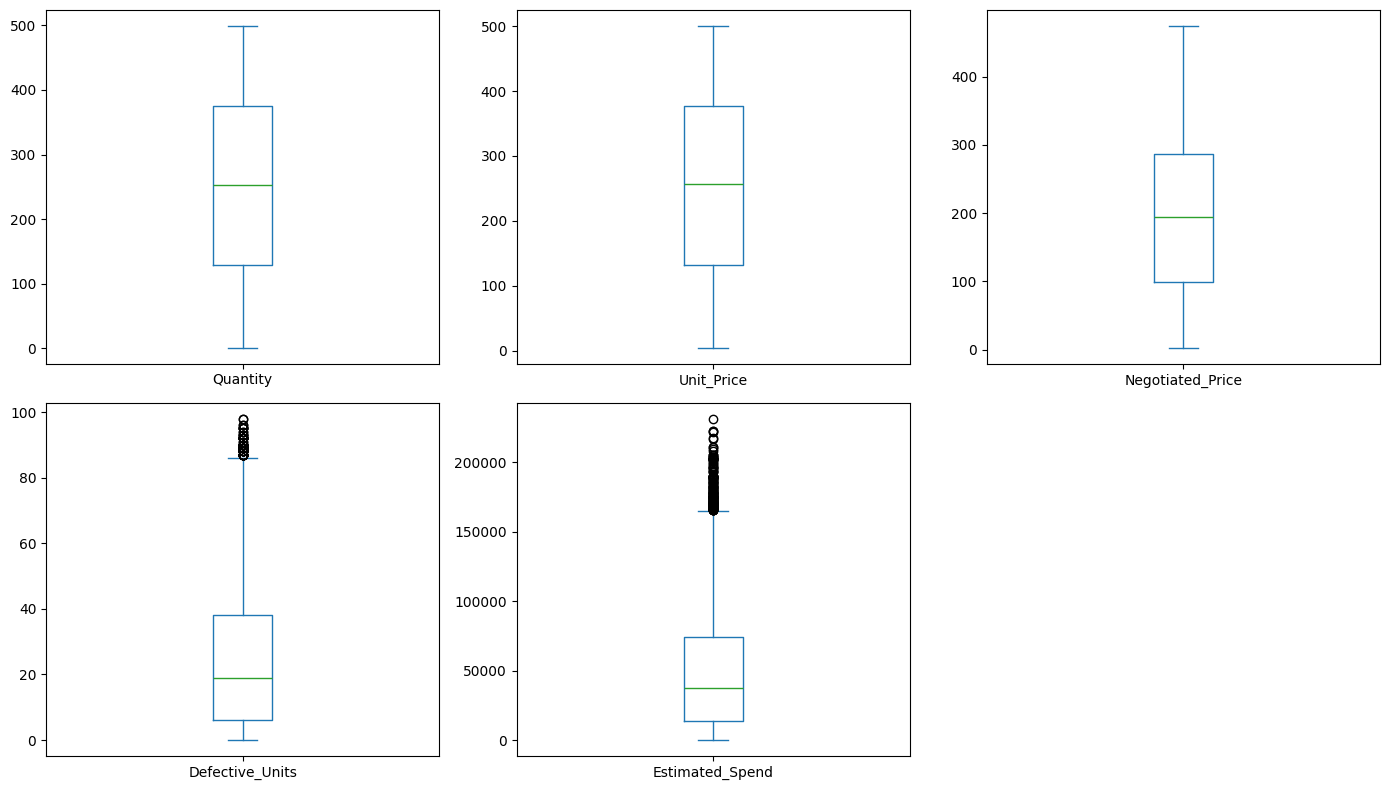

In [40]:
numerical_columns = [
    "Quantity",
    "Unit_Price",
    "Negotiated_Price",
    "Defective_Units",
    "Estimated_Spend"
]

procurement_df[numerical_columns].plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    figsize=(14, 8),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

### Interpretation

The boxplots indicate that the numerical variables exhibit different distribution patterns.

`Quantity`, `Unit_Price` and `Negotiated_Price` show relatively balanced distributions without noticeable extreme observations beyond the whiskers.

In contrast, `Defective_Units` and `Estimated_Spend` contain several observations beyond the upper whisker, indicating the presence of potential outliers.

At this stage, these observations should not be considered erroneous. In a procurement context, unusually large procurement expenditures or higher numbers of defective units may reflect legitimate operational events rather than data quality issues.

Consequently, no observations will be removed during preprocessing. If required, appropriate feature scaling or transformation techniques will be applied later to reduce the influence of extreme values on machine learning algorithms.

## Define the Prediction Target

The objective of this project is to develop a machine learning model capable of predicting supplier compliance based on historical procurement information.

Since supplier operational risk is not explicitly recorded in the dataset, the existing `Compliance` variable is used as the target for binary classification. This variable indicates whether a purchase order complied with the organization's procurement requirements.

Before training predictive models, the distribution of the target classes is examined to identify any potential class imbalance that may influence model training and evaluation.

In [41]:
procurement_df["Compliance"].value_counts()

Compliance
1    7781
0    2219
Name: count, dtype: int64

### Interpretation

The target variable consists of two classes: **7,781 compliant purchase orders (Class 1)** and **2,219 non-compliant purchase orders (Class 0)**.

Although compliant purchase orders represent the majority of observations, both classes remain well represented within the dataset. The class distribution indicates a moderate imbalance that should be considered during model evaluation, particularly when interpreting performance metrics such as precision, recall and F1-score.

# Feature Engineering

To improve predictive performance, additional variables are derived from the existing procurement data.

Rather than relying solely on the original dataset, feature engineering creates business-oriented indicators that better represent supplier performance, procurement efficiency and operational risk. These engineered features are expected to provide machine learning algorithms with more informative patterns than the raw variables alone.

## Create Delivery Lead Time

Delivery lead time measures the number of days between placing a purchase order and receiving the corresponding goods.

This feature is an important operational KPI because supplier responsiveness is often associated with procurement performance. Longer delivery times may indicate operational delays or supplier inefficiencies, making delivery lead time a potentially valuable predictor of supplier compliance.

In [42]:
procurement_df["Delivery_Lead_Time"] = (
    procurement_df["Delivery_Date"] - procurement_df["Order_Date"]
).dt.days

procurement_df[
    [
        "Order_Date",
        "Delivery_Date",
        "Delivery_Lead_Time"
    ]
].head()

,Order_Date,Delivery_Date,Delivery_Lead_Time
0,2023-01-20,2023-03-21,60
1,2023-04-28,2023-07-10,73
2,2023-12-29,2024-04-24,117
3,2023-05-08,2023-08-31,115
4,2023-10-05,2024-01-05,92


## Create Cost Saving

Cost saving represents the monetary reduction achieved through procurement negotiations.

It is calculated as the difference between the original unit price and the negotiated purchase price. This feature captures the financial value generated during the procurement process and may help distinguish suppliers based on their pricing performance.

In [43]:
procurement_df["Cost_Saving"] = (
    procurement_df["Unit_Price"]
    - procurement_df["Negotiated_Price"]
)

procurement_df[
    [
        "Unit_Price",
        "Negotiated_Price",
        "Cost_Saving"
    ]
].head()

,Unit_Price,Negotiated_Price,Cost_Saving
0,7.62,5.11,2.51
1,123.54,87.66,35.88
2,260.42,177.91,82.51
3,358.23,337.02,21.21
4,397.81,318.06,79.75


## Create Saving Rate

Saving rate expresses procurement savings as a percentage of the original unit price.

Unlike absolute cost savings, this relative measure standardizes procurement performance across purchase orders with different price levels. As a result, suppliers can be compared more fairly regardless of the value of the purchased items.

In [44]:
procurement_df["Saving_Rate"] = (
    procurement_df["Cost_Saving"] / procurement_df["Unit_Price"]
) * 100

procurement_df[
    [
        "Cost_Saving",
        "Saving_Rate"
    ]
].head().round(2)


,Cost_Saving,Saving_Rate
0,2.51,32.94
1,35.88,29.04
2,82.51,31.68
3,21.21,5.92
4,79.75,20.05


## Create Defect Rate

Defect rate measures the proportion of defective units within each purchase order.

By normalizing the number of defective units by the order quantity, this feature provides a more meaningful assessment of product quality than using the absolute number of defects alone. Higher defect rates may indicate supplier quality issues and could therefore contribute to predicting supplier compliance.

In [45]:
procurement_df["Defect_Rate"] = (
    procurement_df["Defective_Units"]
    / procurement_df["Quantity"]
) * 100

procurement_df[
    [
        "Quantity",
        "Defective_Units",
        "Defect_Rate"
    ]
].head().round(2)

,Quantity,Defective_Units,Defect_Rate
0,141,6,4.26
1,418,76,18.18
2,328,8,2.44
3,281,42,14.95
4,91,15,16.48


## Remove Obsolete Variables

Following feature engineering, the original date variables are no longer required for predictive modeling.

The relevant temporal information has already been transformed into business-oriented features, such as `Delivery_Lead_Time`. Retaining the original date columns would introduce redundant information without providing additional predictive value.

To simplify the modeling dataset and reduce unnecessary features, the original date variables are removed before model training.

In [46]:
procurement_df = procurement_df.drop(
    columns=[
        "Order_Date",
        "Delivery_Date"
    ]
)

procurement_df.head()

,PO_ID,Supplier,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Estimated_Spend,Delivery_Lead_Time,Cost_Saving,Saving_Rate,Defect_Rate
0,1,RailEngine,Body Structures,Delivered,141,7.62,5.11,6,1,720.51,60,2.51,32.939633,4.255319
1,2,MechaPrime,Bogies & Wheelsets,Delivered,418,123.54,87.66,76,1,36641.88,73,35.88,29.043225,18.181818
2,3,RailCom,HVAC Systems,Delivered,328,260.42,177.91,8,1,58354.48,117,82.51,31.683434,2.439024
3,4,RailMotion,Doors & Access Systems,Delivered,281,358.23,337.02,42,1,94702.62,115,21.21,5.920777,14.946619
4,5,ElectroParts,Brake Systems,Delivered,91,397.81,318.06,15,1,28943.46,92,79.75,20.047259,16.483516


## Prepare Modeling Dataset

The engineered procurement dataset is now organized into a feature matrix and a target variable suitable for supervised machine learning.

The explanatory variables (`X`) contain the operational and financial features used for prediction, while the target variable (`y`) represents supplier compliance. Identifier variables that do not contribute predictive information are excluded from the feature set.

In [47]:
X = procurement_df.drop(columns=["PO_ID", "Compliance"])

y = procurement_df["Compliance"]

## Split Training and Testing Data

To evaluate model performance on unseen data, the dataset is divided into separate training and testing sets.

An 80/20 split is applied, with stratified sampling to preserve the original distribution of compliant and non-compliant purchase orders in both subsets. This ensures that model training and evaluation are performed on representative samples of the procurement data.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)


print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

Training set: (8000, 12)
Testing set: (2000, 12)
Compliance
1    0.778
0    0.222
Name: proportion, dtype: float64
Compliance
1    0.778
0    0.222
Name: proportion, dtype: float64


## Build the Preprocessing Pipeline

The procurement dataset contains both numerical and categorical features, which require different preprocessing strategies before model training.

A preprocessing pipeline is created to automate these transformations. Numerical variables are processed independently from categorical variables before being combined into a unified feature matrix.

Using a pipeline ensures that the same preprocessing steps are applied consistently during both model training and future predictions, reducing the risk of data leakage and improving reproducibility.

In [49]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Supplier', 'Item_Category', 'Order_Status']

Numerical features:
['Quantity', 'Unit_Price', 'Negotiated_Price', 'Defective_Units', 'Estimated_Spend', 'Delivery_Lead_Time', 'Cost_Saving', 'Saving_Rate', 'Defect_Rate']


In [50]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Model Development

To evaluate different machine learning approaches, several supervised classification algorithms are trained using the same training and testing datasets.

Each model is implemented within the same preprocessing pipeline, ensuring that identical data transformations are applied before training. This provides a consistent framework for comparing predictive performance in the evaluation stage.

### Logistic Regression

Logistic Regression is selected as the baseline classification model for this study.

As a linear algorithm, it provides a simple and interpretable reference point against which more complex machine learning models can be compared. Its computational efficiency and ease of interpretation make it a common starting point for binary classification problems.

In [52]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

### Random Forest

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees.

By aggregating numerous trees, the model is able to capture complex relationships within the data while reducing the risk of overfitting associated with individual decision trees. It is widely used for structured datasets and serves as a strong benchmark for classification tasks.

In [53]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

y_pred_rf = random_forest_pipeline.predict(X_test)

### XGBoost

Extreme Gradient Boosting (XGBoost) is a gradient boosting algorithm designed for high-performance supervised learning.

The model sequentially builds decision trees that correct the errors made by previous trees, enabling it to capture complex patterns in structured datasets. XGBoost is widely recognized for its efficiency, scalability and strong predictive capabilities across a broad range of classification problems.

In [54]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

xgboost_pipeline.fit(X_train, y_train)

y_pred_xgb = xgboost_pipeline.predict(X_test)

## Model Evaluation

The predictive models are evaluated using multiple classification metrics to provide a comprehensive assessment of their performance.

Rather than relying on a single indicator, several complementary metrics are used to evaluate the models' ability to correctly classify compliant and non-compliant purchase orders. This approach provides a more balanced comparison and supports the selection of the most suitable model for deployment.

In [55]:
accuracy_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "XGBoost"
        ],
        "Accuracy": [
            accuracy_score(y_test, y_pred_logistic),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_xgb)
        ]
    }
).sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_results.round(2)

,Model,Accuracy
0,Logistic Regression,1.00
2,XGBoost,0.99
1,Random Forest,0.98


### Accuracy Comparison

The three classification models achieved high overall accuracy on the testing dataset, indicating that each model correctly classified the majority of purchase orders.

Although accuracy provides a useful overview of predictive performance, it should not be considered in isolation because the target classes are not perfectly balanced. For this reason, additional evaluation metrics—including precision, recall, F1-score, confusion matrices, and cross-validation—are examined before selecting the final model.

At this stage, the accuracy comparison serves as an initial benchmark rather than the sole criterion for model selection.

### Classification Report

Accuracy provides an overall measure of predictive performance but does not distinguish how well a model classifies each target class.

The classification report complements the accuracy score by presenting precision, recall and F1-score for both compliant and non-compliant purchase orders. These metrics provide a more detailed assessment of each model's strengths and weaknesses, particularly when evaluating class-specific performance.

In [56]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       444
           1       1.00      1.00      1.00      1556

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

Random Forest
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       444
           1       0.99      0.99      0.99      1556

    accuracy                           0.98      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000

XGBoost
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       444
           1       1.00      0.99      1.00      1556

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.9

### Interpretation

The classification reports provide a more detailed assessment of model performance by evaluating precision, recall, and F1-score for each target class.

Across the evaluated models, the performance metrics indicate a high level of predictive capability for both compliant and non-compliant purchase orders. While the reported scores are similar, small differences can be observed in how each model balances precision and recall between the two classes.

These results complement the accuracy comparison by highlighting aspects of model performance that are not captured by overall accuracy alone. The classification report is therefore used together with the confusion matrices and cross-validation results to support the final model selection.

### Confusion Matrix

The confusion matrix provides a detailed view of classification performance by comparing the predicted class with the actual class.

Unlike aggregate metrics such as accuracy, the confusion matrix highlights the number of correct and incorrect predictions for each class. This makes it possible to compare how effectively each model distinguishes compliant and non-compliant purchase orders.

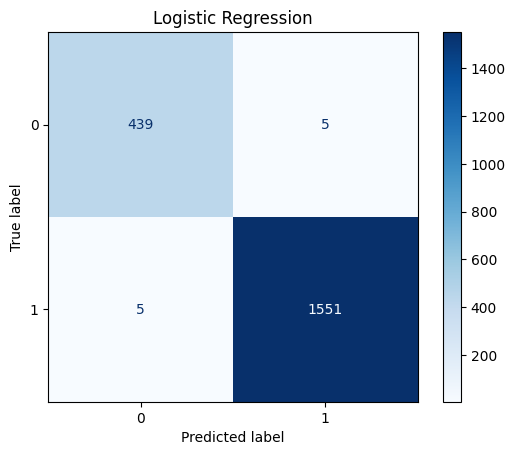

In [57]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

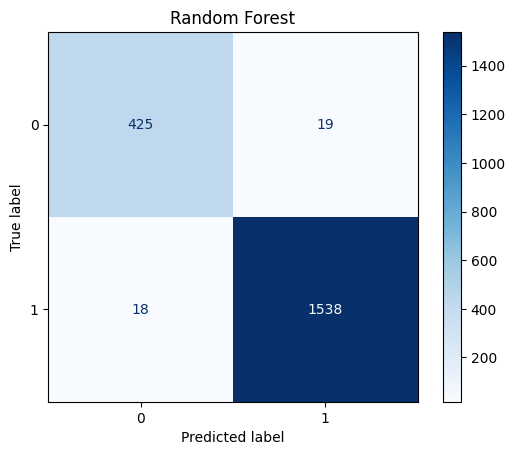

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest")
plt.show()

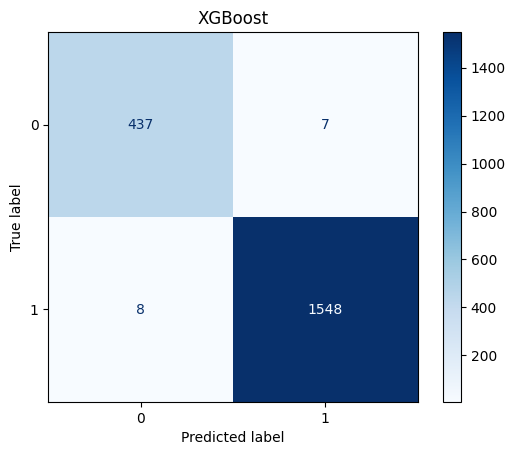

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("XGBoost")
plt.show()

### Interpretation

The confusion matrices provide a straightforward view of where each model makes mistakes by comparing the predicted and actual supplier compliance labels.

Across all three models, the number of incorrect predictions is relatively small, indicating that each algorithm learned the patterns in the engineered procurement dataset effectively. Most purchase orders were classified correctly regardless of the model used.

Logistic Regression produced the fewest classification errors in this evaluation, with only a small number of false positives and false negatives. XGBoost delivered very similar results, while Random Forest made slightly more mistakes, although its overall performance remained strong.

The differences between the models are relatively minor, suggesting that the feature engineering contributed more to the predictive performance than the choice of algorithm itself. For this reason, the confusion matrices should be considered alongside the classification report and cross-validation results before selecting the final model.

Overall, the confusion matrices confirm that all three models provide reliable predictions, with only small differences in their error patterns. The final model selection is therefore based on overall consistency across all evaluation metrics rather than the results of a single test split.


### Cross Validation

The predictive models have been evaluated using a train-test split. To further assess their robustness, an additional validation step is performed using k-fold cross-validation.

Cross-validation repeatedly trains and evaluates each model on different subsets of the dataset, providing a more reliable estimate of its generalization performance.

The **Macro F1-score** is used as the evaluation metric because it assigns equal importance to both classes, making it appropriate for datasets with class imbalance.

In [60]:
logistic_cv = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

rf_cv = cross_val_score(
    random_forest_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

xgboost_cv = cross_val_score(
    xgboost_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

In [61]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Mean Macro F1": [
        logistic_cv.mean(),
        rf_cv.mean(),
        xgboost_cv.mean()
    ],
    "Std": [
        logistic_cv.std(),
        rf_cv.std(),
        xgboost_cv.std()
    ]
})

cv_results.round(2).sort_values(
    by="Mean Macro F1",
    ascending=False
)

,Model,Mean Macro F1,Std
0,Logistic Regression,0.99,0.0
2,XGBoost,0.99,0.0
1,Random Forest,0.98,0.0


### Interpretation

The cross-validation results show that all three models performed consistently across the five validation folds, with very similar Macro F1-scores and almost no variation between runs.

Logistic Regression and XGBoost achieved comparable performance, while Random Forest scored slightly lower. Given the small differences between the models, the results suggest that the engineered features are highly informative and that each algorithm is able to learn the underlying patterns effectively.

The near-zero standard deviations indicate that model performance remained stable across different data splits, providing additional confidence that the observed results are not driven by a single train-test partition.

Overall, cross-validation confirms that each model generalizes well to unseen data. The final model selection is therefore based on the combination of predictive performance, consistency across validation folds, and the results from the previous evaluation metrics rather than on a single performance measure.

## Model Selection

After comparing the predictive performance of the evaluated algorithms, the model with the highest cross-validation Macro F1-score is selected.

This automated selection ensures that the final model is chosen using objective evaluation metrics rather than manual preference, improving the reproducibility of the machine learning workflow.

In [62]:
model_performance = (
    cv_results
    .set_index("Model")["Mean Macro F1"]
    .sort_values(ascending=False)
)

model_performance.round(2)

Model
Logistic Regression    0.99
XGBoost                0.99
Random Forest          0.98
Name: Mean Macro F1, dtype: float64

In [63]:
FINAL_MODEL_NAME = model_performance.index[0]

FINAL_MODEL_NAME

'Logistic Regression'

### Interpretation

The cross-validation results were used to identify the model that demonstrated the strongest overall performance across multiple validation folds. Since the models achieved very similar Macro F1-scores, the final selection was based on the ranking produced by the evaluation pipeline.

In this execution, Logistic Regression was selected as the final model. Although the performance differences between the evaluated algorithms are small, the selected model achieved the highest overall score according to the defined selection criterion.

The chosen model will be exported together with its preprocessing pipeline, ensuring that future data undergo the same transformations before predictions are generated. This guarantees a consistent workflow between model training and deployment.

## Export Model

The selected machine learning pipeline is saved so it can be reused without retraining.

Exporting the complete pipeline preserves both the preprocessing steps and the trained classification model, ensuring that future procurement data are transformed consistently before predictions are generated.

The exported pipeline can be loaded directly by the ProcureSense AI application, providing a consistent workflow between model development and deployment.

In [67]:
MODEL_PIPELINES = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
}

selected_pipeline = MODEL_PIPELINES[FINAL_MODEL_NAME]

joblib.dump(
    selected_pipeline,
    "../models/procuresense_pipeline.pkl",
)

['../models/procuresense_pipeline.pkl']

In [68]:
os.makedirs("../data/prediction", exist_ok=True)

procurement_df.to_csv(
    "../data/prediction/procurement_features.csv",
    index=False
)

print("Dataset saved to ../data/prediction/procurement_features.csv")

Dataset saved to ../data/prediction/procurement_features.csv


# Conclusion
This notebook completed the predictive modeling phase by preparing the engineered procurement dataset, training multiple supervised classification models, and evaluating their predictive performance using a consistent preprocessing and validation workflow.

Logistic Regression, Random Forest, and XGBoost were assessed using complementary evaluation techniques, including classification metrics, confusion matrices, and cross-validation. Together, these analyses provided an objective basis for selecting the model that demonstrated the most suitable balance between predictive performance and generalization.

The selected machine learning pipeline has been exported for deployment, ensuring that the same preprocessing steps and trained model can be reused consistently for future supplier compliance predictions.

This completes the modeling stage of the ProcureSense AI project and provides a reusable predictive pipeline that can be integrated into downstream applications for automated supplier compliance assessment.